<a href="https://colab.research.google.com/github/Chihiro1998/CS5100_FinalProject/blob/main/Dempsey_Center_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

BASE = "https://raw.githubusercontent.com/Chihiro1998/CS5800_FinalProject/main/data/"

df22 = pd.read_excel(BASE + "2022%20Annual%20Client%20Survey%20Data.xlsx", header=1)
df23 = pd.read_excel(BASE + "2023%20Annual%20Client%20Survey%20Data.xlsx", header=1)
df24 = pd.read_excel(BASE + "2024%20Annual%20Client%20Survey.xlsx", header=1)
df25 = pd.read_excel(BASE + "Dempsey%20Center%202025%20Annual%20Client%20Survey.xlsx", header=1)

for name, df in [("2022", df22), ("2023", df23), ("2024", df24), ("2025", df25)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols")

2022: 269 rows, 72 cols
2023: 298 rows, 85 cols
2024: 293 rows, 95 cols
2025: 319 rows, 105 cols



Four annual survey files were loaded using `header=1` to skip
the first row of question text. The 2025 file contains 4 extra
metadata columns at the front, shifting all subsequent column
positions by 4.  
Total respondents across all years: 1,179

In [49]:
# ── Column index mapping ──────────────────────────────────────────
# same question sits at different positions each year
# 2025 has 4 extra metadata cols (ID, collector, start/end time)
# shifting all survey columns right by 4

COL = {
    "sat":           {"2022": 0,  "2023": 0,  "2024": 0,  "2025": 4},
    "life_better":   {"2022": 6,  "2023": 1,  "2024": 1,  "2025": 5},
    "nps":           {"2022": 38, "2023": 45, "2024": 57, "2025": 61},
    "freq":          {"2022": 27, "2023": 22, "2024": 34, "2025": 38},
    "age":           {"2022": 47, "2023": 54, "2024": 67, "2025": 74},
    "gender":        {"2022": 49, "2023": 57, "2024": 71, "2025": 78},
    "cancer_impact": {"2022": 43, "2023": 50, "2024": 63, "2025": 68},
}

# ordinal encoding maps — text responses to numbers for computation
SAT_MAP = {
    "Very Satisfied":                    5,
    "Satisfied":                         4,
    "Neither Satisfied nor Unsatisfied": 3,
    "Unsatisfied":                       2,
    "Very Unsatisfied":                  1,
}
FREQ_MAP = {
    "More than 10 times": 4,
    "6-9 times":          3,
    "2-5 times":          2,
    "1 time":             1,
}

# canonical cancer impact labels used across all downstream cells
CANCER_MAP = {
    "I currently have cancer":                                           "Current Patient",
    "I have had cancer":                                                 "Survivor",
    "I am a care partner to a person who has (or had) cancer":          "Care Partner",
    "I am family member or friend of a person who has (or had) cancer": "Family/Friend",
    "Other/prefer to self-describe:":                                    "Other",
    "Other / prefer to self-describe:":                                  "Other",
}

def extract_year(yr, df):
    n = len(df)

    # age: "Prefer not to answer" is not a valid age group
    age_raw = df.iloc[:, COL["age"][yr]].replace(
        "Prefer not to answer", np.nan
    )

    # life_better: explicit mapping so NaN stays NaN
    # original == "Yes" would silently convert NaN to 0
    life_raw = df.iloc[:, COL["life_better"][yr]]
    life_clean = np.where(
        life_raw == "Yes", 1,
        np.where(life_raw == "No", 0, np.nan)
    )

    # satisfaction: .map() returns NaN for any unrecognised value
    sat_mapped = df.iloc[:, COL["sat"][yr]].map(SAT_MAP)
    unexpected_sat = sat_mapped.isna().sum() - df.iloc[:, COL["sat"][yr]].isna().sum()
    if unexpected_sat > 0:
        print(f"  [{yr}] WARNING: {unexpected_sat} unexpected satisfaction values")

    # freq: same — .map() returns NaN for unrecognised values
    freq_mapped = df.iloc[:, COL["freq"][yr]].map(FREQ_MAP)

    out = pd.DataFrame({
        "year":          np.full(n, yr),
        "satisfaction":  sat_mapped.values,
        "life_better":   life_clean,
        "nps":           pd.to_numeric(
                             df.iloc[:, COL["nps"][yr]], errors="coerce"
                         ).values,
        "freq":          freq_mapped.values,
        "age":           age_raw.values,
        "gender":        df.iloc[:, COL["gender"][yr]].values,
        "cancer_impact": df.iloc[:, COL["cancer_impact"][yr]].values,
    })

    # unify gender labels — wording changed across years
    out["gender"] = out["gender"].replace({
        "Woman / Female / Feminine":       "Woman",
        "Man / Male / Masculine":          "Man",
        "Non-Binary":                      "Non-Binary/Other",
        "Other / Prefer to self-describe": "Non-Binary/Other",
        "Prefer not to say":               "Prefer not to answer",
    })

    # unify cancer impact labels — spacing inconsistency in 2022/2023
    out["cancer_impact"] = out["cancer_impact"].replace({
        "Other / prefer to self-describe:": "Other/prefer to self-describe:"
    })

    # create simplified cancer label for charts and modelling
    out["cancer_simple"] = out["cancer_impact"].replace(CANCER_MAP)

    # 2025 only: calculate response duration from timestamps
    if yr == "2025":
        start = pd.to_datetime(df.iloc[:, 2], errors="coerce")
        end   = pd.to_datetime(df.iloc[:, 3], errors="coerce")
        out["duration_min"] = (end - start).dt.total_seconds().values / 60
    else:
        out["duration_min"] = np.nan

    return out

# ── Build combined dataframe ──────────────────────────────────────
raw   = {"2022": df22, "2023": df23, "2024": df24, "2025": df25}
clean = pd.concat(
    [extract_year(yr, df) for yr, df in raw.items()],
    ignore_index=True
)

print(f"Total rows after combining: {len(clean)}")

# drop rows missing satisfaction — cannot be used in any analysis
before = len(clean)
clean  = clean.dropna(subset=["satisfaction"])
print(f"Rows dropped (no satisfaction score): {before - len(clean)}")
print(f"Final dataset: {len(clean)} rows")

# ── Data quality report ───────────────────────────────────────────
# print missing value counts so cleaning decisions are transparent
print("\nMissing values per column:")
cols_to_check = ["satisfaction", "life_better", "nps",
                 "freq", "age", "gender", "cancer_impact"]
for col in cols_to_check:
    total   = clean[col].isna().sum()
    pct     = total / len(clean) * 100
    per_yr  = clean.groupby("year")[col].apply(lambda x: x.isna().sum())
    print(f"  {col:15s}: {total:3d} total ({pct:.1f}%)  "
          f"by year: {per_yr.to_dict()}")

# ── Summary table ─────────────────────────────────────────────────
summary = clean.groupby("year").agg(
    n          = ("satisfaction", "count"),
    avg_sat    = ("satisfaction", "mean"),
    pct_better = ("life_better",  "mean"),
    avg_nps    = ("nps",          "mean"),
    nps_n      = ("nps",          "count"),
).round(3)
summary["pct_better"] = (summary["pct_better"] * 100).round(1)

print("\nSummary table:")
print(summary)

Total rows after combining: 1179
Rows dropped (no satisfaction score): 0
Final dataset: 1179 rows

Missing values per column:
  satisfaction   :   0 total (0.0%)  by year: {'2022': 0, '2023': 0, '2024': 0, '2025': 0}
  life_better    :   0 total (0.0%)  by year: {'2022': 0, '2023': 0, '2024': 0, '2025': 0}
  nps            :  77 total (6.5%)  by year: {'2022': 0, '2023': 23, '2024': 27, '2025': 27}
  freq           :  48 total (4.1%)  by year: {'2022': 0, '2023': 11, '2024': 18, '2025': 19}
  age            :  98 total (8.3%)  by year: {'2022': 7, '2023': 26, '2024': 32, '2025': 33}
  gender         : 109 total (9.2%)  by year: {'2022': 10, '2023': 28, '2024': 33, '2025': 38}
  cancer_impact  :  94 total (8.0%)  by year: {'2022': 7, '2023': 26, '2024': 30, '2025': 31}

Summary table:
        n  avg_sat  pct_better  avg_nps  nps_n
year                                          
2022  269    4.539        95.2    9.520    269
2023  298    4.436        95.6    9.629    275
2024  293    4.53

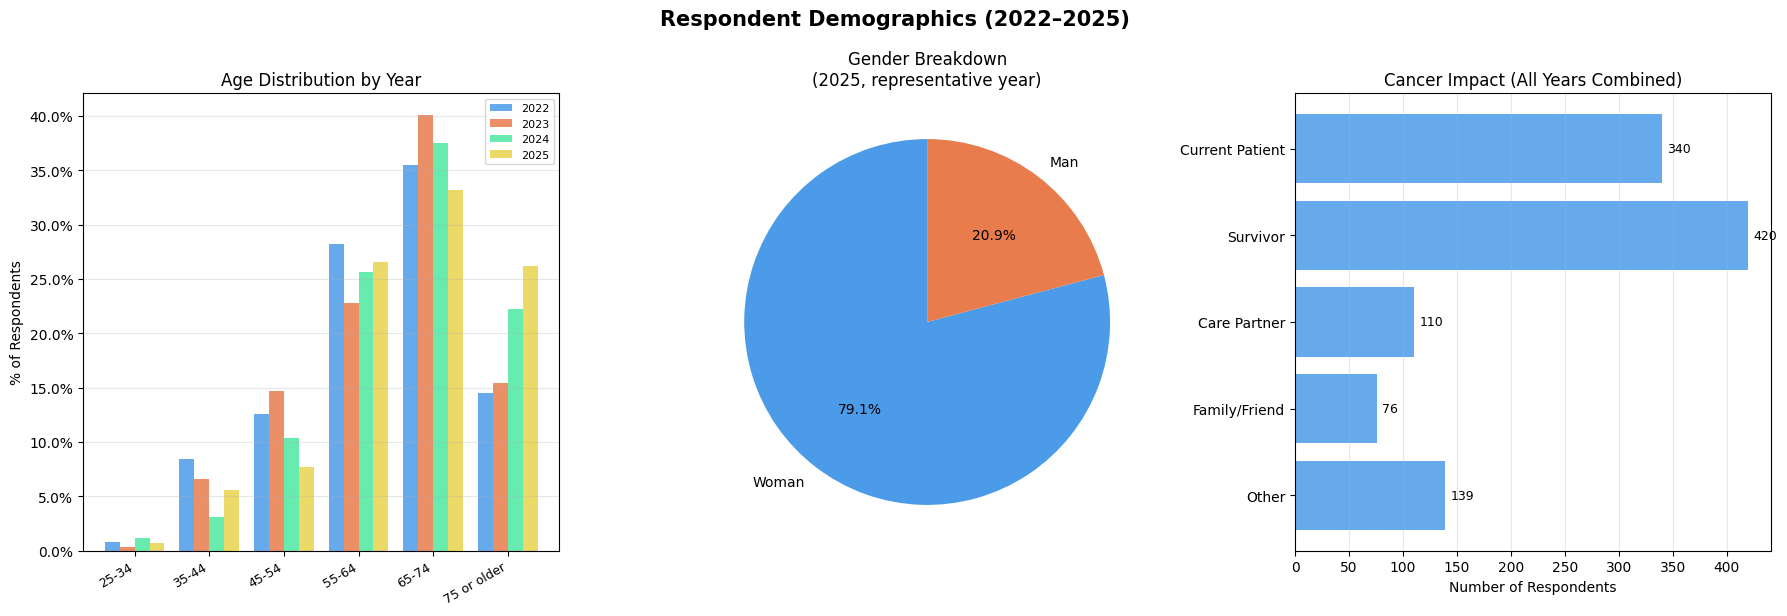

Age distribution (%):
  2022: [np.float64(0.8), np.float64(8.4), np.float64(12.6), np.float64(28.2), np.float64(35.5), np.float64(14.5)]
  2023: [np.float64(0.4), np.float64(6.6), np.float64(14.7), np.float64(22.8), np.float64(40.1), np.float64(15.4)]
  2024: [np.float64(1.1), np.float64(3.1), np.float64(10.3), np.float64(25.7), np.float64(37.5), np.float64(22.2)]
  2025: [np.float64(0.7), np.float64(5.6), np.float64(7.7), np.float64(26.6), np.float64(33.2), np.float64(26.2)]

Gender (2025):
gender
Woman    220
Man       58

Cancer impact (all years):
cancer_simple
Current Patient    340
Survivor           420
Care Partner       110
Family/Friend       76
Other              139


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Respondent Demographics (2022–2025)",
             fontsize=15, fontweight="bold", y=1.02)

years  = ["2022", "2023", "2024", "2025"]
colors = ["#4C9BE8", "#E87C4C", "#4CE8A0", "#E8D44C"]

# ── Chart 1: Age distribution by year ────────────────────────────
ax1 = axes[0]
age_order = ["25-34", "35-44", "45-54", "55-64", "65-74", "75 or older"]

age_data = {}
for yr in years:
    counts = clean[clean["year"] == yr]["age"].value_counts(normalize=True) * 100
    age_data[yr] = [counts.get(a, 0) for a in age_order]

x     = np.arange(len(age_order))
width = 0.2
for i, (yr, color) in enumerate(zip(years, colors)):
    ax1.bar(x + i * width, age_data[yr], width,
            label=yr, color=color, alpha=0.85)

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(age_order, rotation=30, ha="right", fontsize=9)
ax1.set_ylabel("% of Respondents")
ax1.set_title("Age Distribution by Year")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Gender breakdown (2025 as representative year) ──────
# gender distribution is consistent across all years (75–79% women)
# 2025 is used as a representative single-year view
ax2 = axes[1]
gender_counts = clean[clean["year"] == "2025"]["gender"].value_counts()
gender_counts = gender_counts[
    ~gender_counts.index.isin(["Prefer not to answer"])
]

wedge_colors = ["#4C9BE8", "#E87C4C", "#4CE8A0"]
ax2.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors[:len(gender_counts)],
    startangle=90,
    textprops={"fontsize": 10}
)
ax2.set_title("Gender Breakdown\n(2025, representative year)")

# ── Chart 3: Cancer impact across all years ───────────────────────
# cancer_simple was created in Cell 2 using CANCER_MAP
# no need to redefine here
ax3 = axes[2]
impact_order  = ["Current Patient", "Survivor", "Care Partner",
                 "Family/Friend", "Other"]
impact_counts = clean["cancer_simple"].value_counts()
impact_counts = impact_counts.reindex(
    [i for i in impact_order if i in impact_counts.index]
)

bars = ax3.barh(impact_counts.index, impact_counts.values,
                color="#4C9BE8", alpha=0.85)
for bar, val in zip(bars, impact_counts.values):
    ax3.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=9)

ax3.set_xlabel("Number of Respondents")
ax3.set_title("Cancer Impact (All Years Combined)")
ax3.invert_yaxis()
ax3.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("demographics.png", bbox_inches="tight", dpi=150)
plt.show()

# print exact numbers for the report
print("Age distribution (%):")
for yr in years:
    print(f"  {yr}: {[round(v,1) for v in age_data[yr]]}")

print("\nGender (2025):")
print(gender_counts.to_string())

print("\nCancer impact (all years):")
print(impact_counts.to_string())

Gender distribution is shown for 2025 as a representative year.
The distribution across all four years is consistent:
women represent 75–79% of respondents annually.

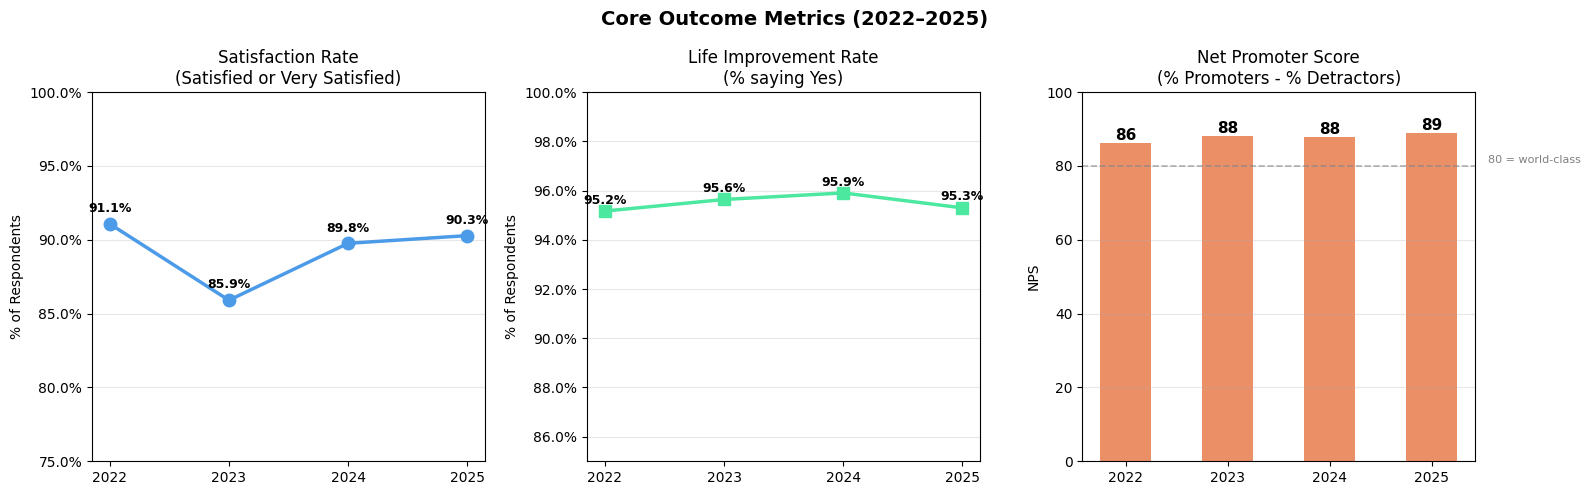

Satisfaction %: ['91.1', '85.9', '89.8', '90.3']
Life Better %:  ['95.2', '95.6', '95.9', '95.3']
NPS scores:     ['86', '88', '88', '89']


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Core Outcome Metrics (2022–2025)", fontsize=14, fontweight="bold")

years = ["2022", "2023", "2024", "2025"]

# % Satisfied or Very Satisfied (satisfaction score >= 4)
sat_pct = [
    (clean[clean["year"] == yr]["satisfaction"] >= 4).mean() * 100
    for yr in years
]

# % saying life improved (life_better == 1)
better_pct = [
    clean[clean["year"] == yr]["life_better"].mean() * 100
    for yr in years
]

# NPS = % promoters (9-10) minus % detractors (0-6)
def calc_nps(yr):
    vals       = clean[clean["year"] == yr]["nps"].dropna()
    promoters  = (vals >= 9).mean() * 100
    detractors = (vals <= 6).mean() * 100
    return promoters - detractors

nps_scores = [calc_nps(yr) for yr in years]

# ── Chart 1: Satisfaction trend ───────────────────────────────────
ax1 = axes[0]
ax1.plot(years, sat_pct, marker="o", linewidth=2.5,
         color="#4C9BE8", markersize=9)
for i, v in enumerate(sat_pct):
    ax1.text(i, v + 0.8, f"{v:.1f}%", ha="center",
             fontsize=9, fontweight="bold")
ax1.set_ylim(75, 100)
ax1.set_title("Satisfaction Rate\n(Satisfied or Very Satisfied)")
ax1.set_ylabel("% of Respondents")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Life Better trend ────────────────────────────────────
ax2 = axes[1]
ax2.plot(years, better_pct, marker="s", linewidth=2.5,
         color="#4CE8A0", markersize=9)
for i, v in enumerate(better_pct):
    ax2.text(i, v + 0.3, f"{v:.1f}%", ha="center",
             fontsize=9, fontweight="bold")
ax2.set_ylim(85, 100)
ax2.set_title("Life Improvement Rate\n(% saying Yes)")
ax2.set_ylabel("% of Respondents")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: NPS by year ──────────────────────────────────────────
# reference line at 80 = industry threshold for world-class
ax3 = axes[2]
bars = ax3.bar(years, nps_scores, color="#E87C4C", alpha=0.85, width=0.5)
for bar, v in zip(bars, nps_scores):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.8,
             f"{v:.0f}", ha="center", fontsize=11, fontweight="bold")
ax3.axhline(y=80, color="gray", linestyle="--", linewidth=1.2, alpha=0.6)
ax3.text(3.55, 80.8, "80 = world-class", fontsize=8, color="gray")
ax3.set_ylim(0, 100)
ax3.set_title("Net Promoter Score\n(% Promoters - % Detractors)")
ax3.set_ylabel("NPS")
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("core_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

print("Satisfaction %:", [f"{v:.1f}" for v in sat_pct])
print("Life Better %: ", [f"{v:.1f}" for v in better_pct])
print("NPS scores:    ", [f"{v:.0f}"  for v in nps_scores])

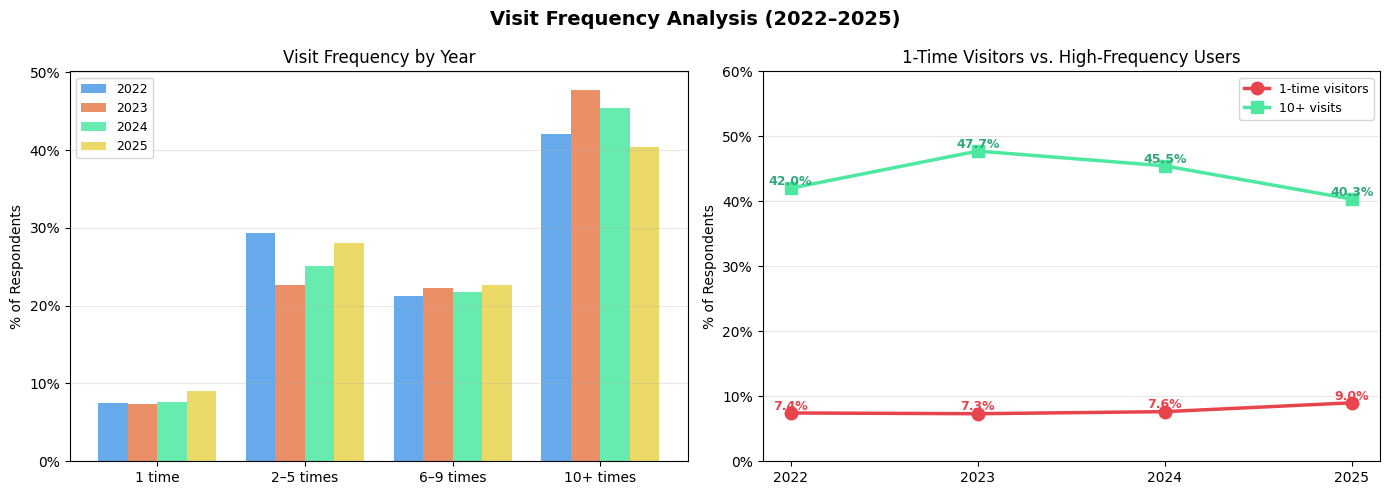

1-time visitor %:   ['7.4', '7.3', '7.6', '9.0']
10+ visit %:        ['42.0', '47.7', '45.5', '40.3']
2022: ['7.4%', '29.4%', '21.2%', '42.0%']
2023: ['7.3%', '22.6%', '22.3%', '47.7%']
2024: ['7.6%', '25.1%', '21.8%', '45.5%']
2025: ['9.0%', '28.0%', '22.7%', '40.3%']


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Visit Frequency Analysis (2022–2025)", fontsize=14, fontweight="bold")

years = ["2022", "2023", "2024", "2025"]
freq_labels = ["1 time", "2–5 times", "6–9 times", "10+ times"]
freq_vals   = [1, 2, 3, 4]

# compute % for each frequency tier per year
freq_data = {}
for yr in years:
    counts = clean[clean["year"] == yr]["freq"].value_counts(normalize=True) * 100
    freq_data[yr] = [counts.get(v, 0) for v in freq_vals]

# ── Chart 1: grouped bar chart ────────────────────────────────────
ax1 = axes[0]
x = np.arange(len(freq_labels))
width = 0.2

for i, (yr, color) in enumerate(zip(years, ["#4C9BE8","#E87C4C","#4CE8A0","#E8D44C"])):
    bars = ax1.bar(x + i * width, freq_data[yr], width,
                   label=yr, color=color, alpha=0.85)

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(freq_labels, fontsize=10)
ax1.set_ylabel("% of Respondents")
ax1.set_title("Visit Frequency by Year")
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: 1-time visitor trend line ───────────────────────────
# isolate the 1-time visitor % to highlight the 2025 uptick
ax2 = axes[1]
one_time = [freq_data[yr][0] for yr in years]   # index 0 = "1 time"
high_freq = [freq_data[yr][3] for yr in years]  # index 3 = "10+ times"

ax2.plot(years, one_time,  marker="o", linewidth=2.5,
         color="#E8444C", markersize=9, label="1-time visitors")
ax2.plot(years, high_freq, marker="s", linewidth=2.5,
         color="#4CE8A0", markersize=9, label="10+ visits")

for i, (v1, v2) in enumerate(zip(one_time, high_freq)):
    ax2.text(i, v1 + 0.5, f"{v1:.1f}%", ha="center", fontsize=9,
             color="#E8444C", fontweight="bold")
    ax2.text(i, v2 + 0.5, f"{v2:.1f}%", ha="center", fontsize=9,
             color="#2ea87a", fontweight="bold")

ax2.set_ylim(0, 60)
ax2.set_title("1-Time Visitors vs. High-Frequency Users")
ax2.set_ylabel("% of Respondents")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("visit_frequency.png", bbox_inches="tight", dpi=150)
plt.show()

# print exact numbers for the report
print("1-time visitor %:  ", [f"{v:.1f}" for v in one_time])
print("10+ visit %:       ", [f"{v:.1f}" for v in high_freq])
for yr in years:
    print(f"{yr}: {[f'{v:.1f}%' for v in freq_data[yr]]}")

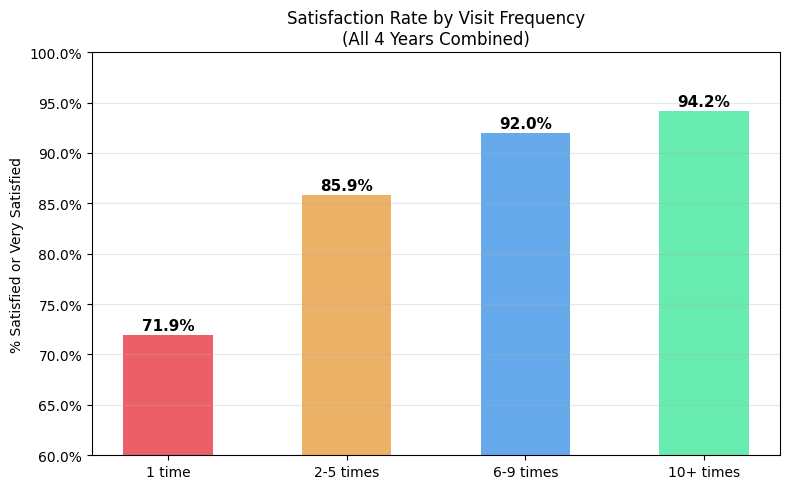

In [53]:
# show satisfaction rate by visit frequency tier across all 4 years
freq_labels = {1: "1 time", 2: "2-5 times", 3: "6-9 times", 4: "10+ times"}
clean["freq_label"] = clean["freq"].map(freq_labels)

freq_order = ["1 time", "2-5 times", "6-9 times", "10+ times"]
sat_by_freq = (
    clean.groupby("freq_label")["satisfaction"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reindex(freq_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sat_by_freq.index, sat_by_freq.values,
              color=["#E8444C","#E8A44C","#4C9BE8","#4CE8A0"],
              alpha=0.85, width=0.5)
for bar, v in zip(bars, sat_by_freq.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(60, 100)
ax.set_ylabel("% Satisfied or Very Satisfied")
ax.set_title("Satisfaction Rate by Visit Frequency\n(All 4 Years Combined)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("freq_vs_satisfaction.png", bbox_inches="tight", dpi=150)
plt.show()

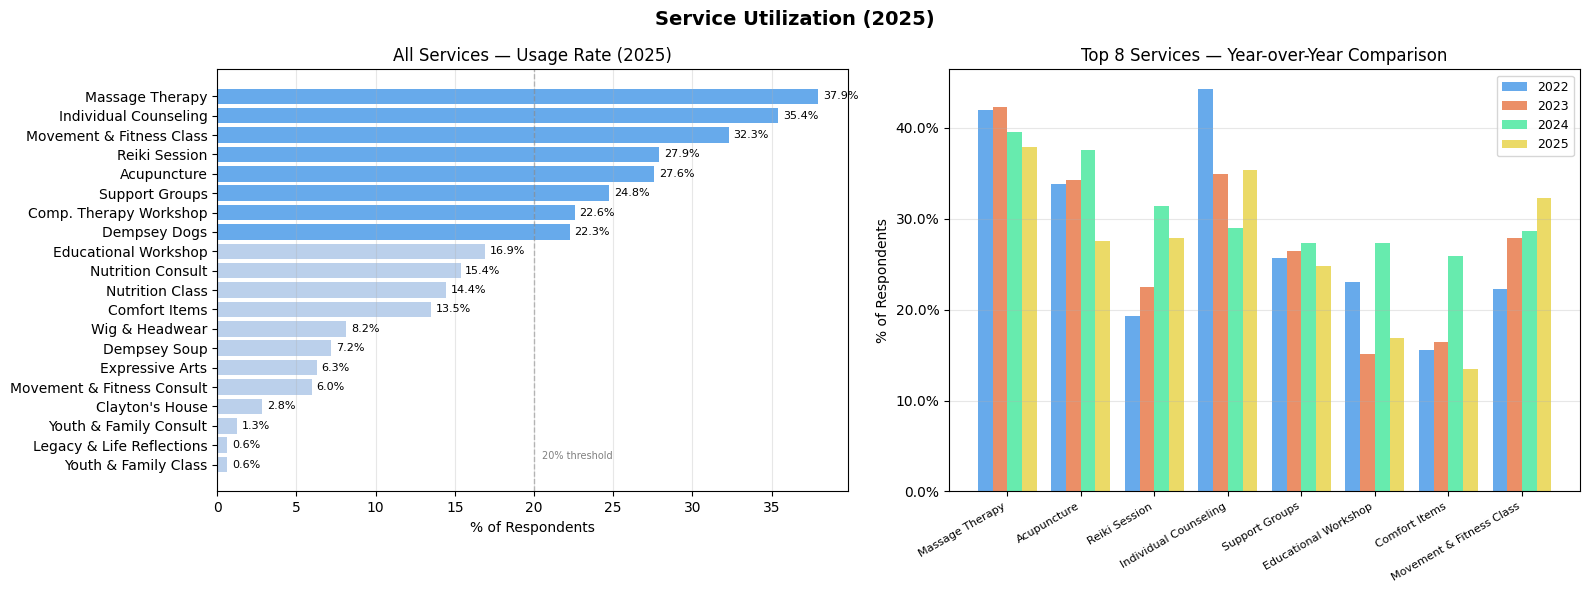


Top 10 services by usage rate (2025):
Massage Therapy             37.9
Individual Counseling       35.4
Movement & Fitness Class    32.3
Reiki Session               27.9
Acupuncture                 27.6
Support Groups              24.8
Comp. Therapy Workshop      22.6
Dempsey Dogs                22.3
Educational Workshop        16.9
Nutrition Consult           15.4


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Service Utilization (2025)", fontsize=14, fontweight="bold")

df25_raw = df25  # using the raw 2025 file

# service columns in 2025 (after header=1 load)
# cols 16-21: comfort/wellness services
# cols 23-31: complementary therapies
# cols 33-37: counseling services
service_cols = {
    "Clayton's House":               16,
    "Comfort Items":                 17,
    "Dempsey Dogs":                  18,
    "Educational Workshop":          19,
    "Expressive Arts":               20,
    "Wig & Headwear":                21,
    "Acupuncture":                   23,
    "Comp. Therapy Workshop":        24,
    "Dempsey Soup":                  25,
    "Massage Therapy":               26,
    "Movement & Fitness Consult":    27,
    "Movement & Fitness Class":      28,
    "Nutrition Consult":             29,
    "Nutrition Class":               30,
    "Reiki Session":                 31,
    "Individual Counseling":         33,
    "Legacy & Life Reflections":     34,
    "Support Groups":                35,
    "Youth & Family Consult":        36,
    "Youth & Family Class":          37,
}

# usage rate = % of respondents who used each service (non-null = used)
usage = {}
for name, col in service_cols.items():
    usage[name] = df25_raw.iloc[:, col].notna().mean() * 100

usage_series = pd.Series(usage).sort_values(ascending=True)

# ── Chart 1: all services ranked ─────────────────────────────────
ax1 = axes[0]
colors_bar = ["#4C9BE8" if v >= 20 else "#B0C8E8" for v in usage_series.values]
bars = ax1.barh(usage_series.index, usage_series.values,
                color=colors_bar, alpha=0.85)
for bar, val in zip(bars, usage_series.values):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=8)
ax1.set_xlabel("% of Respondents")
ax1.set_title("All Services — Usage Rate (2025)")
ax1.axvline(x=20, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax1.text(20.5, 0.3, "20% threshold", fontsize=7, color="gray")
ax1.grid(axis="x", alpha=0.3)

# ── Chart 2: top 8 services across all 4 years ───────────────────

# find equivalent cols in other years
# manually mapped based on service name matching
service_cols_by_year = {
    "Massage Therapy":        {"2022": 17, "2023": 12, "2024": 22, "2025": 26},
    "Acupuncture":            {"2022":  7, "2023":  2, "2024": 19, "2025": 23},
    "Reiki Session":          {"2022": 22, "2023": 17, "2024": 27, "2025": 31},
    "Individual Counseling":  {"2022":  8, "2023": 10, "2024": 29, "2025": 33},
    "Support Groups":         {"2022":  9, "2023": 18, "2024": 31, "2025": 35},
    "Educational Workshop":   {"2022": 14, "2023":  8, "2024": 15, "2025": 19},
    "Comfort Items":          {"2022": 10, "2023":  4, "2024": 13, "2025": 17},
    "Movement & Fitness Class":{"2022":19, "2023": 13, "2024": 24, "2025": 28},
}

raw_dfs = {"2022": df22, "2023": df23, "2024": df24, "2025": df25}
year_colors = ["#4C9BE8", "#E87C4C", "#4CE8A0", "#E8D44C"]

ax2 = axes[1]
x = np.arange(len(service_cols_by_year))
width = 0.2

for i, (yr, color) in enumerate(zip(years, year_colors)):
    rates = []
    for svc, cols in service_cols_by_year.items():
        col_idx = cols[yr]
        rate = raw_dfs[yr].iloc[:, col_idx].notna().mean() * 100
        rates.append(rate)
    ax2.bar(x + i * width, rates, width, label=yr, color=color, alpha=0.85)

ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(service_cols_by_year.keys(), rotation=30,
                    ha="right", fontsize=8)
ax2.set_ylabel("% of Respondents")
ax2.set_title("Top 8 Services — Year-over-Year Comparison")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("service_utilization.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nTop 10 services by usage rate (2025):")
print(usage_series.nlargest(10).round(1).to_string())

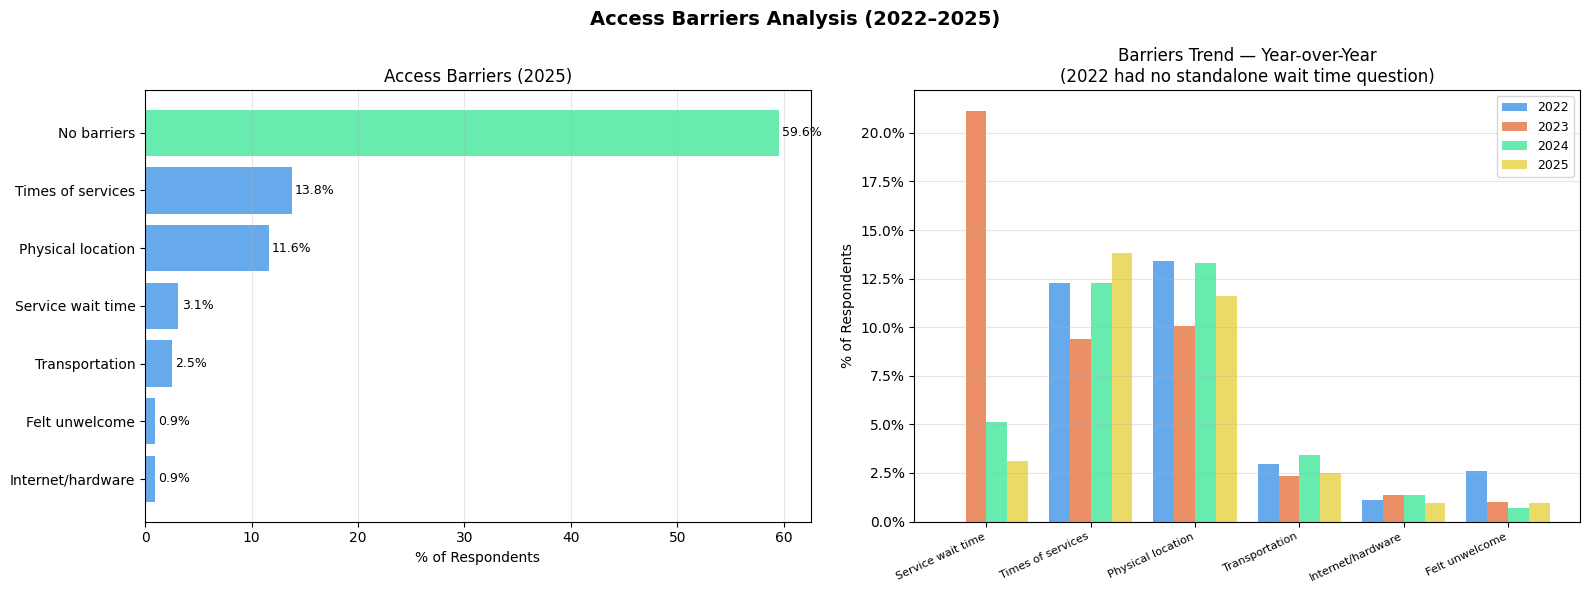


Access barriers — all years:
  No barriers           : ['64.3%', '55.7%', '58.0%', '59.6%']
  Service wait time     : ['N/A', '21.1%', '5.1%', '3.1%']
  Times of services     : ['12.3%', '9.4%', '12.3%', '13.8%']
  Physical location     : ['13.4%', '10.1%', '13.3%', '11.6%']
  Transportation        : ['3.0%', '2.3%', '3.4%', '2.5%']
  Internet/hardware     : ['1.1%', '1.3%', '1.4%', '0.9%']
  Felt unwelcome        : ['2.6%', '1.0%', '0.7%', '0.9%']


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Access Barriers Analysis (2022–2025)", fontsize=14, fontweight="bold")

# corrected column indices — verified against actual Excel column names
# 2022 did not have a standalone "service wait time" question
barrier_cols_by_year = {
    "No barriers":       {"2022": 28, "2023": 23, "2024": 35, "2025": 39},
    "Service wait time": {"2022": None,"2023": 24, "2024": 36, "2025": 40},
    "Times of services": {"2022": 30, "2023": 26, "2024": 38, "2025": 42},
    "Physical location": {"2022": 31, "2023": 27, "2024": 39, "2025": 43},
    "Transportation":    {"2022": 32, "2023": 28, "2024": 40, "2025": 44},
    "Internet/hardware": {"2022": 33, "2023": 29, "2024": 41, "2025": 45},
    "Felt unwelcome":    {"2022": 34, "2023": 30, "2024": 42, "2025": 46},
}

raw_dfs = {"2022": df22, "2023": df23, "2024": df24, "2025": df25}
years   = ["2022", "2023", "2024", "2025"]

# compute % per barrier per year — skip years where col is None
barrier_data = {}
for barrier, cols in barrier_cols_by_year.items():
    barrier_data[barrier] = []
    for yr in years:
        col_idx = cols[yr]
        if col_idx is None:
            barrier_data[barrier].append(np.nan)
        else:
            rate = raw_dfs[yr].iloc[:, col_idx].notna().mean() * 100
            barrier_data[barrier].append(rate)

# ── Chart 1: 2025 barrier breakdown ──────────────────────────────
ax1 = axes[0]
barriers_2025 = {k: v[3] for k, v in barrier_data.items()}
barriers_2025 = dict(sorted(barriers_2025.items(), key=lambda x: x[1]))

bar_colors = ["#4CE8A0" if k == "No barriers" else "#4C9BE8"
              for k in barriers_2025.keys()]
bars = ax1.barh(list(barriers_2025.keys()), list(barriers_2025.values()),
                color=bar_colors, alpha=0.85)
for bar, val in zip(bars, barriers_2025.values()):
    ax1.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=9)
ax1.set_xlabel("% of Respondents")
ax1.set_title("Access Barriers (2025)")
ax1.grid(axis="x", alpha=0.3)

# ── Chart 2: barrier trends over 4 years ─────────────────────────
ax2 = axes[1]
year_colors  = ["#4C9BE8", "#E87C4C", "#4CE8A0", "#E8D44C"]
plot_barriers = [b for b in barrier_cols_by_year if b != "No barriers"]

x     = np.arange(len(plot_barriers))
width = 0.2

for i, (yr, color) in enumerate(zip(years, year_colors)):
    rates = [barrier_data[b][i] for b in plot_barriers]
    # replace NaN with 0 for display only
    rates_display = [r if not np.isnan(r) else 0 for r in rates]
    ax2.bar(x + i * width, rates_display, width,
            label=yr, color=color, alpha=0.85)

ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(plot_barriers, rotation=25, ha="right", fontsize=8)
ax2.set_ylabel("% of Respondents")
ax2.set_title("Barriers Trend — Year-over-Year\n(2022 had no standalone wait time question)")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("access_barriers.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nAccess barriers — all years:")
for barrier, vals in barrier_data.items():
    formatted = [f"{v:.1f}%" if not np.isnan(v) else "N/A" for v in vals]
    print(f"  {barrier:22s}: {formatted}")

Feature matrix: 1179 rows x 16 feature cols
Rows by year: {'2022': 269, '2023': 298, '2024': 293, '2025': 319}


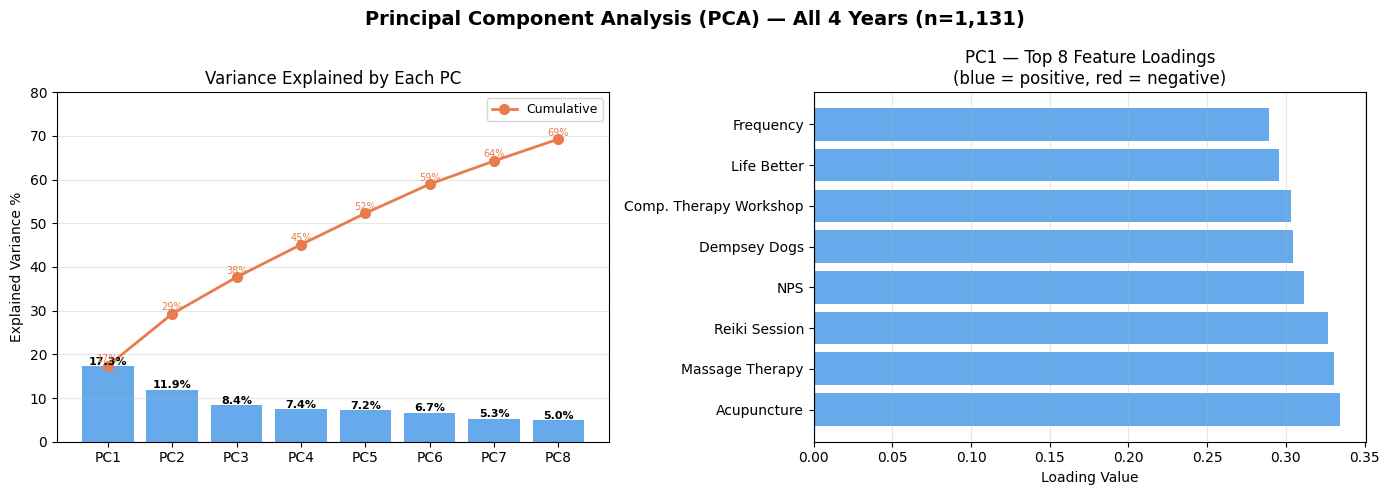


Explained variance per PC:
  PC1: 17.3%  (cumulative: 17.3%)
  PC2: 11.9%  (cumulative: 29.3%)
  PC3: 8.4%  (cumulative: 37.7%)
  PC4: 7.4%  (cumulative: 45.1%)
  PC5: 7.2%  (cumulative: 52.3%)
  PC6: 6.7%  (cumulative: 58.9%)
  PC7: 5.3%  (cumulative: 64.3%)
  PC8: 5.0%  (cumulative: 69.3%)

PC1 top features:
Acupuncture               0.334
Massage Therapy           0.331
Reiki Session             0.327
NPS                       0.311
Dempsey Dogs              0.304
Comp. Therapy Workshop    0.303
Life Better               0.296
Frequency                 0.289
Name: PC1, dtype: float64

PC2 top features:
Life Better        0.390
NPS                0.384
Acupuncture        0.311
Comfort Items      0.296
Massage Therapy    0.289
Reiki Session      0.284
Frequency          0.277
Support Groups     0.273
Name: PC2, dtype: float64


In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# service columns verified across all 4 years
# these 12 services exist consistently in all survey years
SERVICE_COLS = {
    "Massage Therapy":          {"2022": 17, "2023": 12, "2024": 22, "2025": 26},
    "Acupuncture":              {"2022":  7, "2023":  2, "2024": 19, "2025": 23},
    "Reiki Session":            {"2022": 22, "2023": 17, "2024": 27, "2025": 31},
    "Individual Counseling":    {"2022":  8, "2023": 10, "2024": 29, "2025": 33},
    "Support Groups":           {"2022":  9, "2023": 18, "2024": 31, "2025": 35},
    "Movement & Fitness Class": {"2022": 19, "2023": 13, "2024": 24, "2025": 28},
    "Nutrition Consult":        {"2022": 20, "2023": 15, "2024": 25, "2025": 29},
    "Comfort Items":            {"2022": 10, "2023":  4, "2024": 13, "2025": 17},
    "Educational Workshop":     {"2022": 14, "2023":  8, "2024": 15, "2025": 19},
    "Dempsey Dogs":             {"2022": 12, "2023":  6, "2024": 14, "2025": 18},
    "Comp. Therapy Workshop":   {"2022": 11, "2023":  5, "2024": 20, "2025": 24},
    "Wig & Headwear":           {"2022": 23, "2023": 19, "2024": 17, "2025": 21},
}

raw_dfs = {"2022": df22, "2023": df23, "2024": df24, "2025": df25}

# build binary service matrix from all 4 years
svc_rows = []
for yr, df in raw_dfs.items():
    sub = pd.DataFrame()
    for svc, cols in SERVICE_COLS.items():
        sub[svc] = df.iloc[:, cols[yr]].notna().astype(int).values
    sub["year"] = yr
    svc_rows.append(sub)

svc_all = pd.concat(svc_rows, ignore_index=True)

# attach outcome variables from clean (same row order)
feat = svc_all.copy()
feat["Satisfaction"] = clean["satisfaction"].values
feat["NPS"]          = clean["nps"].values
feat["Frequency"]    = clean["freq"].values
feat["Life Better"]  = clean["life_better"].values

# drop rows missing satisfaction or frequency
feat = feat.dropna(subset=["Satisfaction"])
print(f"Feature matrix: {feat.shape[0]} rows x {feat.shape[1]-1} feature cols")
print(f"Rows by year: {feat['year'].value_counts().sort_index().to_dict()}")

# impute NaN (NPS has ~77 missing), then standardize
feat_cols = [c for c in feat.columns if c != "year"]
imputer   = SimpleImputer(strategy="most_frequent")
X         = imputer.fit_transform(feat[feat_cols])
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

# run PCA
pca   = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

# ── Plot 1: explained variance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Principal Component Analysis (PCA) — All 4 Years",
             fontsize=14, fontweight="bold")

ax1 = axes[0]
var_ratio  = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(var_ratio)
pc_labels  = [f"PC{i+1}" for i in range(len(var_ratio))]

bars = ax1.bar(pc_labels, var_ratio, color="#4C9BE8", alpha=0.85)
ax1.plot(pc_labels, cumulative, color="#E87C4C", marker="o",
         linewidth=2, markersize=7, label="Cumulative")

for bar, v in zip(bars, var_ratio):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.3,
             f"{v:.1f}%", ha="center", fontsize=8, fontweight="bold")
for i, cv in enumerate(cumulative):
    ax1.text(i, cv + 0.8, f"{cv:.0f}%", ha="center",
             fontsize=7, color="#E87C4C")

ax1.set_ylabel("Explained Variance %")
ax1.set_title("Variance Explained by Each PC")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim(0, 80)

# ── Plot 2: PC1 top feature loadings ─────────────────────────────
ax2 = axes[1]
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feat_cols,
    columns=["PC1", "PC2"]
)

top_pc1    = loadings["PC1"].abs().nlargest(8).index
pc1_vals   = loadings.loc[top_pc1, "PC1"]
colors_load = ["#4C9BE8" if v > 0 else "#E8444C" for v in pc1_vals]
ax2.barh(top_pc1, pc1_vals, color=colors_load, alpha=0.85)
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.set_xlabel("Loading Value")
ax2.set_title("PC1 — Top 8 Feature Loadings\n(blue = positive, red = negative)")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("pca_results.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nExplained variance per PC:")
for i, (v, cv) in enumerate(zip(var_ratio, cumulative)):
    print(f"  PC{i+1}: {v:.1f}%  (cumulative: {cv:.1f}%)")

print("\nPC1 top features:")
print(loadings["PC1"].abs().nlargest(8).round(3))
print("\nPC2 top features:")
print(loadings["PC2"].abs().nlargest(8).round(3))

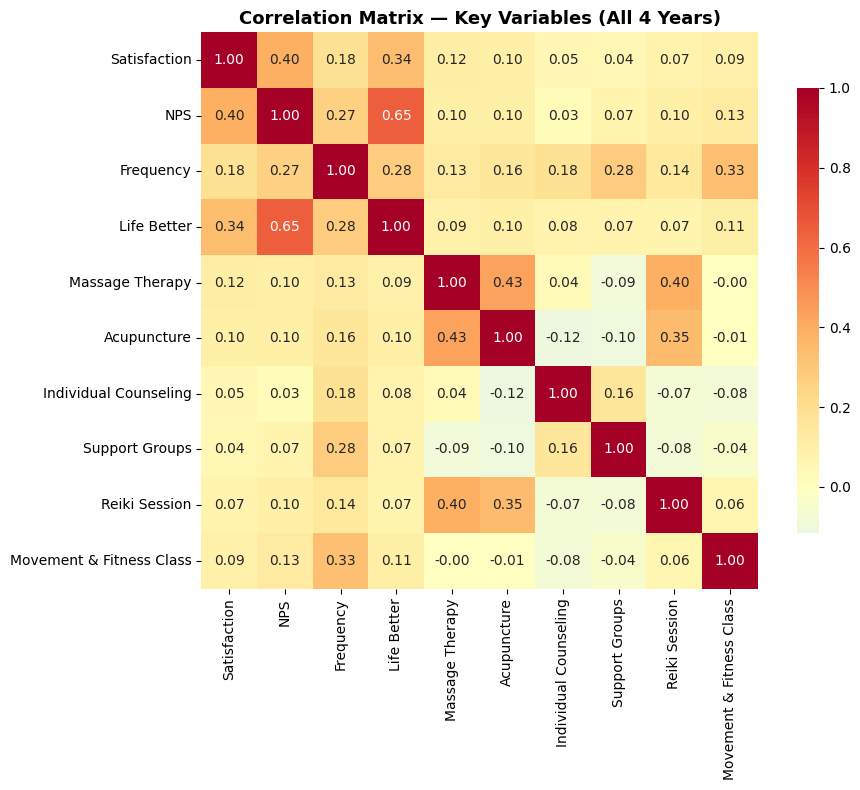

In [64]:
import seaborn as sns

# confirm these column names exist in feat
corr_cols = ["Satisfaction", "NPS", "Frequency", "Life Better",
             "Massage Therapy", "Acupuncture", "Individual Counseling",
             "Support Groups", "Reiki Session", "Movement & Fitness Class"]

# check all requested columns exist
missing = [c for c in corr_cols if c not in feat.columns]
if missing:
    print(f"WARNING: columns not found in feat: {missing}")
else:
    corr_df     = feat[corr_cols].copy()
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r",
                center=0, square=True, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title("Correlation Matrix — Key Variables (All 4 Years)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("correlation_matrix.png", bbox_inches="tight", dpi=150)
    plt.show()

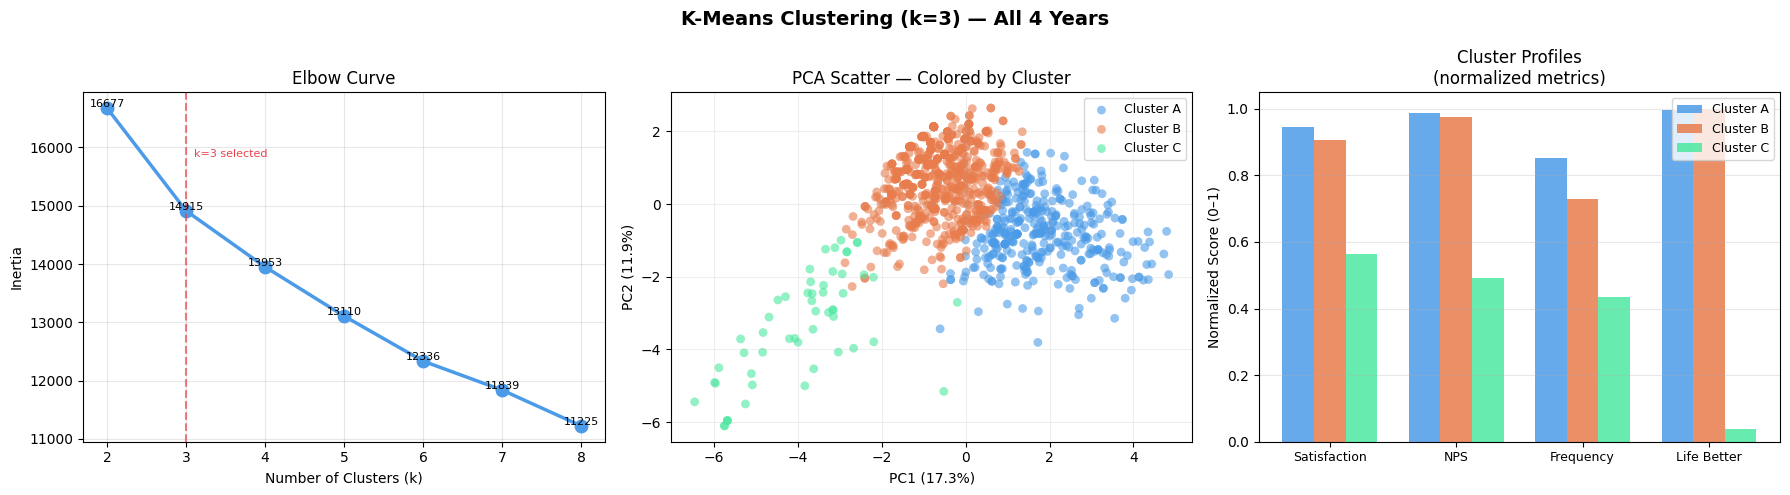

Cluster sizes:
cluster
0    365
1    760
2     54
Name: count, dtype: int64

Cluster mean profiles:
         Satisfaction   NPS  Frequency  Life Better
cluster                                            
0                4.72  9.88       3.40         1.00
1                4.53  9.74       2.91         1.00
2                2.81  4.91       1.74         0.04

Top 3 services per cluster:
  Cluster 0: ['Massage Therapy', 'Acupuncture', 'Reiki Session']
  Cluster 1: ['Individual Counseling', 'Support Groups', 'Movement & Fitness Class']
  Cluster 2: ['Individual Counseling', 'Massage Therapy', 'Comfort Items']


In [65]:
from sklearn.cluster import KMeans

# ── Step 1: elbow curve ───────────────────────────────────────────
inertias = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# ── Step 2: final model with k=3 ─────────────────────────────────
km3    = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km3.fit_predict(X_scaled)
feat["cluster"] = labels

# ── Step 3: plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Means Clustering (k=3) — All 4 Years",
             fontsize=14, fontweight="bold")

# Chart 1: elbow curve
ax1 = axes[0]
ax1.plot(list(k_range), inertias, marker="o", linewidth=2.5,
         color="#4C9BE8", markersize=9)
for k, v in zip(k_range, inertias):
    ax1.text(k, v + 20, str(round(v)), ha="center", fontsize=8)
ax1.axvline(x=3, color="#E8444C", linestyle="--", alpha=0.7, linewidth=1.5)
ax1.text(3.1, max(inertias) * 0.95, "k=3 selected",
         fontsize=8, color="#E8444C")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Curve")
ax1.grid(alpha=0.3)

# Chart 2: PCA scatter colored by cluster
# read PC variance % from pca object instead of hardcoding
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

ax2 = axes[1]
cluster_colors = {0: "#4C9BE8", 1: "#E87C4C", 2: "#4CE8A0"}
cluster_names  = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C"}

for c in [0, 1, 2]:
    mask = labels == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cluster_colors[c], label=cluster_names[c],
                alpha=0.6, s=40, edgecolors="none")

ax2.set_xlabel(f"PC1 ({pc1_var:.1f}%)")
ax2.set_ylabel(f"PC2 ({pc2_var:.1f}%)")
ax2.set_title("PCA Scatter — Colored by Cluster")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

# Chart 3: cluster profiles (normalized)
ax3 = axes[2]
profile_cols  = ["Satisfaction", "NPS", "Frequency", "Life Better"]
cluster_means = feat.groupby("cluster")[profile_cols].mean()

cluster_means_norm = cluster_means.copy()
cluster_means_norm["Satisfaction"] = cluster_means["Satisfaction"] / 5
cluster_means_norm["NPS"]          = cluster_means["NPS"] / 10
cluster_means_norm["Frequency"]    = cluster_means["Frequency"] / 4

x     = np.arange(len(profile_cols))
width = 0.25

for i, (c, color) in enumerate(cluster_colors.items()):
    vals = cluster_means_norm.loc[c, profile_cols].values
    ax3.bar(x + i * width, vals, width,
            label=cluster_names[c], color=color, alpha=0.85)

ax3.set_xticks(x + width)
ax3.set_xticklabels(profile_cols, fontsize=9)
ax3.set_ylabel("Normalized Score (0–1)")
ax3.set_title("Cluster Profiles\n(normalized metrics)")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_clustering.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Step 4: cluster summary ───────────────────────────────────────
print("Cluster sizes:")
print(feat["cluster"].value_counts().sort_index())

print("\nCluster mean profiles:")
print(feat.groupby("cluster")[profile_cols].mean().round(2))

# exclude non-service columns when finding top services
exclude = profile_cols + ["cluster", "year"]
svc_cols = [c for c in feat.columns if c not in exclude]

print("\nTop 3 services per cluster:")
for c in [0, 1, 2]:
    mask = feat["cluster"] == c
    top  = feat.loc[mask, svc_cols].mean().nlargest(3)
    print(f"  Cluster {c}: {list(top.index)}")

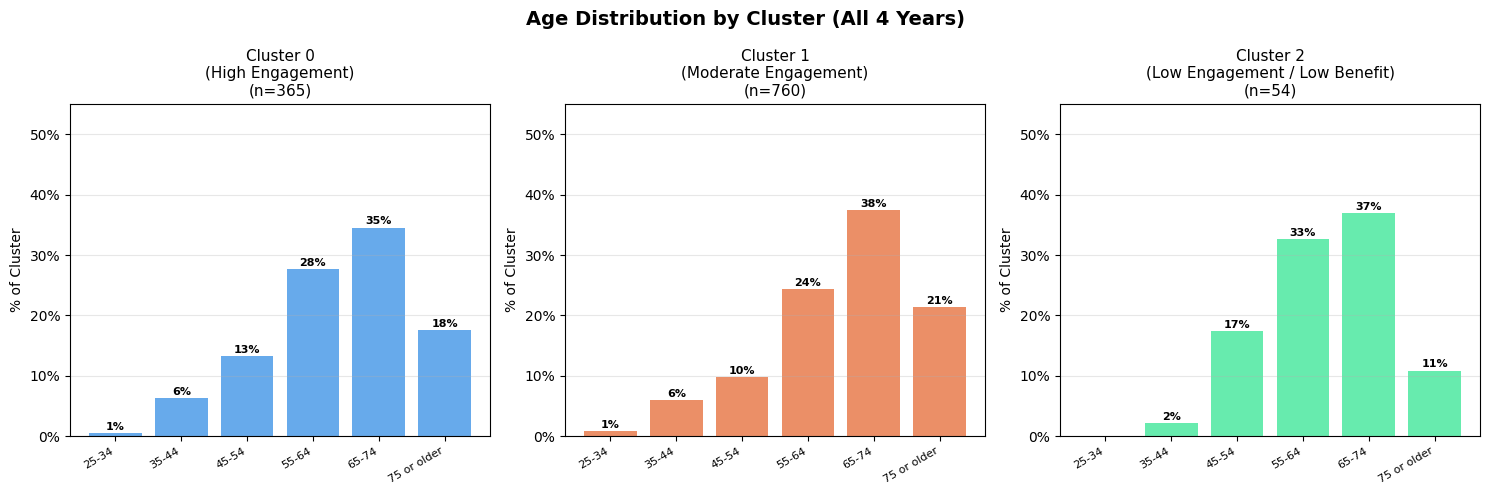

Age distribution by cluster (%):

Cluster 0 (n=365):
  25-34: 0.6%
  35-44: 6.2%
  45-54: 13.3%
  55-64: 27.8%
  65-74: 34.6%
  75 or older: 17.6%

Cluster 1 (n=760):
  25-34: 0.9%
  35-44: 6.0%
  45-54: 9.8%
  55-64: 24.3%
  65-74: 37.5%
  75 or older: 21.4%

Cluster 2 (n=54):
  25-34: 0.0%
  35-44: 2.2%
  45-54: 17.4%
  55-64: 32.6%
  65-74: 37.0%
  75 or older: 10.9%


In [66]:
# attach cluster labels to full clean dataframe (all 4 years)
# feat and clean have the same row order — both 1179 rows
clean_clustered = clean.reset_index(drop=True).copy()
clean_clustered["cluster"] = feat["cluster"].values

age_order = ["25-34", "35-44", "45-54", "55-64", "65-74", "75 or older"]

# update cluster names to match the new 4-year results
cluster_names = {
    0: "Cluster 0\n(High Engagement)",
    1: "Cluster 1\n(Moderate Engagement)",
    2: "Cluster 2\n(Low Engagement / Low Benefit)",
}
cluster_colors = {0: "#4C9BE8", 1: "#E87C4C", 2: "#4CE8A0"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Age Distribution by Cluster (All 4 Years)",
             fontsize=14, fontweight="bold")

for c in [0, 1, 2]:
    ax   = axes[c]
    mask = clean_clustered["cluster"] == c
    counts = (clean_clustered.loc[mask, "age"]
              .value_counts(normalize=True) * 100)
    vals = [counts.get(a, 0) for a in age_order]

    bars = ax.bar(age_order, vals, color=cluster_colors[c], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                    f"{v:.0f}%", ha="center", fontsize=8, fontweight="bold")

    ax.set_title(f"{cluster_names[c]}\n(n={mask.sum()})", fontsize=11)
    ax.set_ylabel("% of Cluster")
    ax.set_ylim(0, 55)
    ax.set_xticklabels(age_order, rotation=30, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_age_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("Age distribution by cluster (%):")
for c in [0, 1, 2]:
    mask = clean_clustered["cluster"] == c
    counts = (clean_clustered.loc[mask, "age"]
              .value_counts(normalize=True) * 100)
    print(f"\nCluster {c} (n={mask.sum()}):")
    for age in age_order:
        print(f"  {age}: {counts.get(age, 0):.1f}%")

Dataset: 1050 rows (all 4 years)
High satisfaction: 947 (90.2%)
Low satisfaction:  103 (9.8%)

Test accuracy: 65.7%

Classification Report:
              precision    recall  f1-score   support

     Low Sat       0.13      0.43      0.20        21
    High Sat       0.91      0.68      0.78       189

    accuracy                           0.66       210
   macro avg       0.52      0.56      0.49       210
weighted avg       0.84      0.66      0.72       210



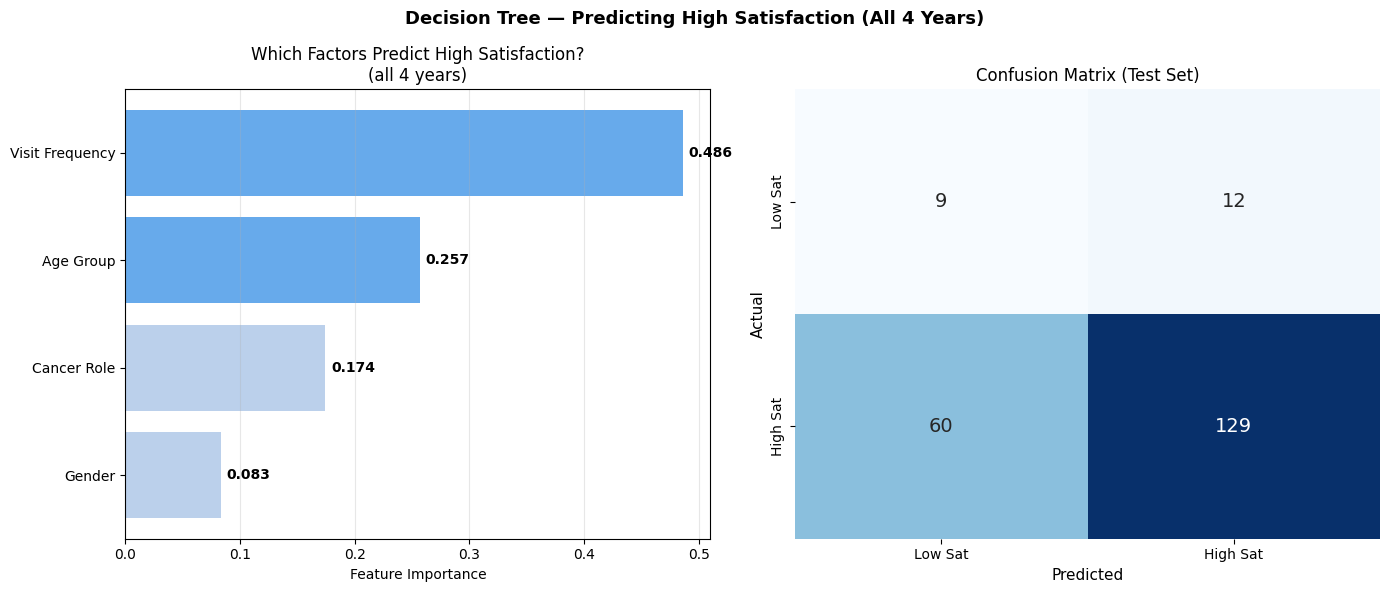


Feature importance ranked:
  Visit Frequency: 0.4859
  Age Group: 0.2565
  Cancer Role: 0.1743
  Gender: 0.0833


In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# use all 4 years for a more reliable training sample
# 2025-only had only 28 low-satisfaction cases — too few to train on

age_map = {
    "25-34": 1, "35-44": 2, "45-54": 3,
    "55-64": 4, "65-74": 5, "75 or older": 6
}
gender_map = {"Woman": 0, "Man": 1, "Non-Binary/Other": 2}
cancer_map = {
    "I currently have cancer":                                           0,
    "I have had cancer":                                                 1,
    "I am a care partner to a person who has (or had) cancer":          2,
    "I am family member or friend of a person who has (or had) cancer": 3,
    "Other/prefer to self-describe:":                                    4,
    "Other / prefer to self-describe:":                                  4,
}

dt_df = clean.copy()
dt_df["age_num"]    = dt_df["age"].map(age_map)
dt_df["gender_num"] = dt_df["gender"].map(gender_map)
dt_df["cancer_num"] = dt_df["cancer_impact"].map(cancer_map)

dt_df["high_sat"] = (dt_df["satisfaction"] >= 4).astype(int)

feature_cols = [
    "freq", "age_num", "cancer_num", "gender_num"
]

dt_df = dt_df.dropna(subset=feature_cols + ["high_sat"])
X_dt  = dt_df[feature_cols]
y_dt  = dt_df["high_sat"]

print(f"Dataset: {len(dt_df)} rows (all 4 years)")
print(f"High satisfaction: {y_dt.sum()} ({y_dt.mean()*100:.1f}%)")
print(f"Low satisfaction:  {(1-y_dt).sum()} ({(1-y_dt).mean()*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

dt = DecisionTreeClassifier(max_depth=4, random_state=42,
                             class_weight="balanced")
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(f"\nTest accuracy: {(y_pred == y_test).mean()*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Low Sat", "High Sat"]))

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Decision Tree — Predicting High Satisfaction (All 4 Years)",
             fontsize=13, fontweight="bold")

labels_map = {
    "freq":       "Visit Frequency",
    "age_num":    "Age Group",
    "cancer_num": "Cancer Role",
    "gender_num": "Gender",
}

ax1 = axes[0]
importance = pd.Series(dt.feature_importances_,
                       index=[labels_map[c] for c in feature_cols])
importance = importance.sort_values()
bar_colors = ["#4C9BE8" if v >= importance.max() * 0.4
              else "#B0C8E8" for v in importance.values]
bars = ax1.barh(importance.index, importance.values,
                color=bar_colors, alpha=0.85)
for bar, v in zip(bars, importance.values):
    ax1.text(bar.get_width() + 0.005,
             bar.get_y() + bar.get_height() / 2,
             f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Feature Importance")
ax1.set_title("Which Factors Predict High Satisfaction?\n(all 4 years)")
ax1.grid(axis="x", alpha=0.3)

ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Sat", "High Sat"],
            yticklabels=["Low Sat", "High Sat"],
            ax=ax2, cbar=False, annot_kws={"size": 14})
ax2.set_xlabel("Predicted", fontsize=11)
ax2.set_ylabel("Actual", fontsize=11)
ax2.set_title("Confusion Matrix (Test Set)")

plt.tight_layout()
plt.savefig("decision_tree.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nFeature importance ranked:")
for name, v in importance.sort_values(ascending=False).items():
    print(f"  {name}: {v:.4f}")

Test 1: Cancer Role vs Satisfaction (all 4 years, n=1179)
high_sat         High Satisfaction  Low Satisfaction
cancer_simple                                       
Care Partner                   100                10
Current Patient                313                27
Family/Friend                   69                 7
Other                          119                20
Survivor                       374                46
Chi-square: 5.067 | df: 4 | p-value: 0.2804
Not statistically significant

Test 2: Visit Frequency vs Satisfaction (all 4 years, n=1179)
high_sat    High Satisfaction  Low Satisfaction
freq_label                                     
1 time                     64                25
10+ times                 467                29
2-5 times                 255                42
6-9 times                 229                20
Chi-square: 47.438 | df: 3 | p-value: 0.0000
Statistically significant


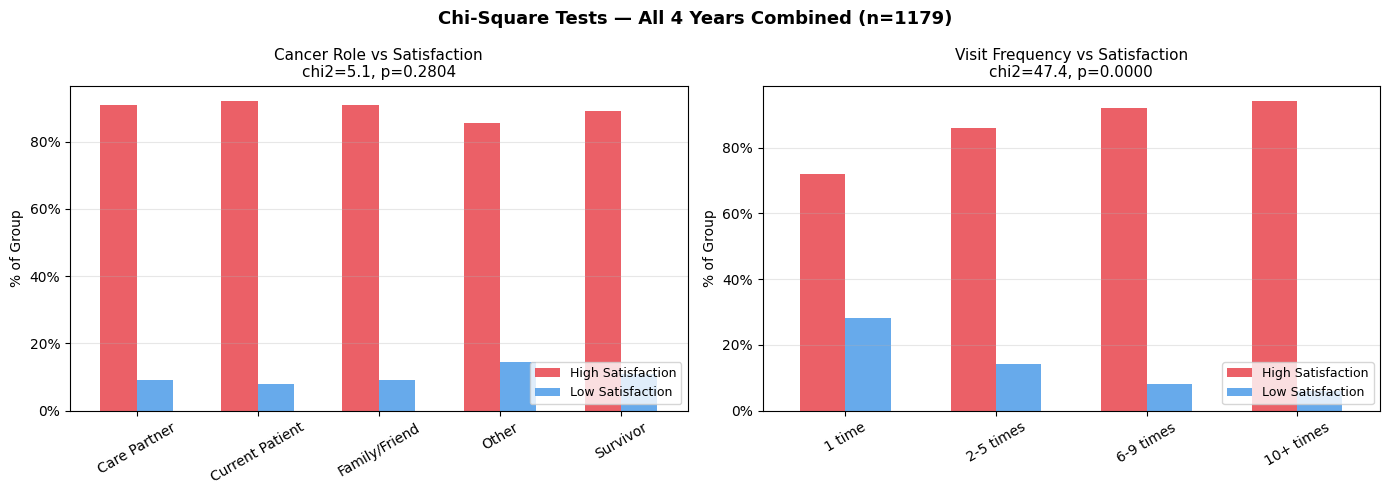


Summary (n=1179, all years):
  Cancer Role x Satisfaction     p = 0.2804  - not significant
  Visit Frequency x Satisfaction p = 0.0000  - significant


In [61]:
from scipy.stats import chi2_contingency

# run chi-square on all 4 years combined for larger sample size
# this gives more reliable results than 2025 alone

cancer_simple = {
    "I currently have cancer":                                           "Current Patient",
    "I have had cancer":                                                 "Survivor",
    "I am a care partner to a person who has (or had) cancer":          "Care Partner",
    "I am family member or friend of a person who has (or had) cancer": "Family/Friend",
    "Other/prefer to self-describe:":                                    "Other",
    "Other / prefer to self-describe:":                                  "Other",
}

all_test = clean.copy()
all_test["high_sat"] = (all_test["satisfaction"] >= 4).map(
    {True: "High Satisfaction", False: "Low Satisfaction"}
)
all_test["cancer_simple"] = all_test["cancer_impact"].replace(cancer_simple)

# Test 1: Cancer Role
ct1 = pd.crosstab(all_test["cancer_simple"], all_test["high_sat"])
chi2_1, p1, dof1, _ = chi2_contingency(ct1)

print("Test 1: Cancer Role vs Satisfaction (all 4 years, n=1179)")
print(ct1)
print(f"Chi-square: {chi2_1:.3f} | df: {dof1} | p-value: {p1:.4f}")
print("Not statistically significant" if p1 >= 0.05 else "Statistically significant")

# Test 2: Visit Frequency
freq_labels = {1: "1 time", 2: "2-5 times", 3: "6-9 times", 4: "10+ times"}
all_test["freq_label"] = all_test["freq"].map(freq_labels)

ct2 = pd.crosstab(all_test["freq_label"], all_test["high_sat"])
chi2_2, p2, dof2, _ = chi2_contingency(ct2)

print("\nTest 2: Visit Frequency vs Satisfaction (all 4 years, n=1179)")
print(ct2)
print(f"Chi-square: {chi2_2:.3f} | df: {dof2} | p-value: {p2:.4f}")
print("Not statistically significant" if p2 >= 0.05 else "Statistically significant")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chi-Square Tests — All 4 Years Combined (n=1179)",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
ct1_pct = ct1.div(ct1.sum(axis=1), axis=0) * 100
ct1_pct.plot(kind="bar", ax=ax1, color=["#E8444C", "#4C9BE8"],
             alpha=0.85, width=0.6)
ax1.set_title(f"Cancer Role vs Satisfaction\nchi2={chi2_1:.1f}, p={p1:.4f}",
              fontsize=11)
ax1.set_ylabel("% of Group")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=30)
ax1.legend(loc="lower right", fontsize=9)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[1]
freq_order = ["1 time", "2-5 times", "6-9 times", "10+ times"]
ct2_ordered = ct2.reindex([f for f in freq_order if f in ct2.index])
ct2_pct = ct2_ordered.div(ct2_ordered.sum(axis=1), axis=0) * 100
ct2_pct.plot(kind="bar", ax=ax2, color=["#E8444C", "#4C9BE8"],
             alpha=0.85, width=0.6)
ax2.set_title(f"Visit Frequency vs Satisfaction\nchi2={chi2_2:.1f}, p={p2:.4f}",
              fontsize=11)
ax2.set_ylabel("% of Group")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)
ax2.legend(loc="lower right", fontsize=9)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chi_square_tests.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\nSummary (n=1179, all years):")
print(f"  Cancer Role x Satisfaction     p = {p1:.4f}  - not significant")
print(f"  Visit Frequency x Satisfaction p = {p2:.4f}  - significant")


Chi-square tests of independence verify whether the associations
found in the Decision Tree are statistically reliable.

Both tests use all four years (n=1,179) to match the Decision Tree
training data and ensure sufficient sample size.